In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)

DATA_DIR = Path("../data/raw")
print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
# See exactly what BETH gave us
files = list(DATA_DIR.glob("*.csv"))
for f in files:
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"{f.name:45s} → {size_mb:.2f} MB")

labelled_2021may-ip-10-100-1-105-dns.csv      → 0.04 MB
labelled_2021may-ip-10-100-1-105.csv          → 94.95 MB
labelled_2021may-ip-10-100-1-186-dns.csv      → 0.04 MB
labelled_2021may-ip-10-100-1-186.csv          → 161.03 MB
labelled_2021may-ip-10-100-1-26-dns.csv       → 0.04 MB
labelled_2021may-ip-10-100-1-26.csv           → 85.35 MB
labelled_2021may-ip-10-100-1-4-dns.csv        → 0.04 MB
labelled_2021may-ip-10-100-1-4.csv            → 109.66 MB
labelled_2021may-ip-10-100-1-95-dns.csv       → 0.04 MB
labelled_2021may-ip-10-100-1-95.csv           → 108.46 MB
labelled_2021may-ubuntu-dns.csv               → 0.04 MB
labelled_2021may-ubuntu.csv                   → 39.36 MB
labelled_testing_data.csv                     → 54.64 MB
labelled_training_data.csv                    → 188.21 MB
labelled_validation_data.csv                  → 43.31 MB


In [3]:
train_df = pd.read_csv(DATA_DIR / "labelled_training_data.csv")
val_df   = pd.read_csv(DATA_DIR / "labelled_validation_data.csv")
test_df  = pd.read_csv(DATA_DIR / "labelled_testing_data.csv")

print("=== DATASET SHAPES ===")
print(f"Training   : {train_df.shape[0]:>10,} rows × {train_df.shape[1]} cols")
print(f"Validation : {val_df.shape[0]:>10,} rows × {val_df.shape[1]} cols")
print(f"Testing    : {test_df.shape[0]:>10,} rows × {test_df.shape[1]} cols")
print(f"Total      : {train_df.shape[0]+val_df.shape[0]+test_df.shape[0]:>10,} rows")

=== DATASET SHAPES ===
Training   :    763,144 rows × 16 cols
Validation :    188,967 rows × 16 cols
Testing    :    188,967 rows × 16 cols
Total      :  1,141,078 rows


In [4]:
print("=== COLUMNS & DTYPES ===")
print(train_df.dtypes)
print("\n=== FIRST 3 ROWS ===")
train_df.head(3)

=== COLUMNS & DTYPES ===
timestamp          float64
processId            int64
threadId             int64
parentProcessId      int64
userId               int64
mountNamespace       int64
processName         object
hostName            object
eventId              int64
eventName           object
stackAddresses      object
argsNum              int64
returnValue          int64
args                object
sus                  int64
evil                 int64
dtype: object

=== FIRST 3 ROWS ===


,timestamp,processId,threadId,parentProcessId,userId,mountNamespace,processName,hostName,eventId,eventName,stackAddresses,argsNum,returnValue,args,sus,evil
0,1809.495787,381,7337,1,100,4026532231,close,ip-10-100-1-120,157,prctl,"[140662171848350, 11649800180280676]",5,0,"[{'name': 'option', 'type': 'int', 'value': 'P...",1,0
1,1809.495832,381,7337,1,100,4026532231,close,ip-10-100-1-120,3,close,[140662171777451],1,0,"[{'name': 'fd', 'type': 'int', 'value': 19}]",1,0
2,1809.495921,381,7337,1,100,4026532231,close,ip-10-100-1-120,1010,sched_process_exit,[],0,0,[],1,0


In [5]:
print("=== LABEL DISTRIBUTION IN TEST SET ===")
print("\n--- 'sus' column (suspicious behavior) ---")
print(test_df['sus'].value_counts())
print(f"\nSuspicious rate: {test_df['sus'].mean()*100:.4f}%")

print("\n--- 'evil' column (confirmed attacker) ---")
print(test_df['evil'].value_counts())
print(f"\nEvil rate: {test_df['evil'].mean()*100:.4f}%")

print("\n--- Training set labels (should be ALL zeros) ---")
print("sus unique values:", train_df['sus'].unique())
print("evil unique values:", train_df['evil'].unique())

=== LABEL DISTRIBUTION IN TEST SET ===

--- 'sus' column (suspicious behavior) ---
sus
1    171459
0     17508
Name: count, dtype: int64

Suspicious rate: 90.7349%

--- 'evil' column (confirmed attacker) ---
evil
1    158432
0     30535
Name: count, dtype: int64

Evil rate: 83.8411%

--- Training set labels (should be ALL zeros) ---
sus unique values: [1 0]
evil unique values: [0]


In [6]:
print("=== NULL VALUES IN TRAINING DATA ===")
nulls = train_df.isnull().sum()
nulls_pct = (nulls / len(train_df) * 100).round(2)
null_report = pd.DataFrame({'null_count': nulls, 'null_pct': nulls_pct})
print(null_report[null_report['null_count'] > 0])

if null_report['null_count'].sum() == 0:
    print("No nulls found ✅")

=== NULL VALUES IN TRAINING DATA ===
Empty DataFrame
Columns: [null_count, null_pct]
Index: []
No nulls found ✅


In [7]:
print("=== USER ID DISTRIBUTION ===")
uid_counts = train_df['userId'].value_counts().head(20)
print(uid_counts)

print("\n=== PRIVILEGE ZONE BREAKDOWN ===")
print(f"Root (UID=0)         : {(train_df['userId']==0).sum():>8,} events")
print(f"Daemon (UID 1-999)   : {((train_df['userId']>=1) & (train_df['userId']<=999)).sum():>8,} events")
print(f"External (UID 1000+) : {(train_df['userId']>=1000).sum():>8,} events")

=== USER ID DISTRIBUTION ===
userId
0       754907
101       3398
109       1476
102       1208
100       1148
1000       996
103         11
Name: count, dtype: int64

=== PRIVILEGE ZONE BREAKDOWN ===
Root (UID=0)         :  754,907 events
Daemon (UID 1-999)   :    7,241 events
External (UID 1000+) :      996 events


In [8]:
print("=== TOP 20 PROCESS NAMES IN TRAINING (Normal Behavior) ===")
print(train_df['processName'].value_counts().head(20))

print("\n=== TOP 20 PROCESS NAMES IN TEST SET (Contains Attacks) ===")
print(test_df['processName'].value_counts().head(20))

# Rare processes — these are red flags
rare_train = train_df['processName'].value_counts()
print(f"\n=== RARE PROCESSES (appear < 5 times in training) ===")
print(rare_train[rare_train < 5])

=== TOP 20 PROCESS NAMES IN TRAINING (Normal Behavior) ===
processName
ps                 406313
systemd-udevd      189292
sshd                91762
systemd-journal     20421
systemd             17310
systemd-tmpfile     13014
amazon-ssm-agen      4850
snapd                4187
cron                 4080
systemd-resolve      3398
systemd-user-ru      1276
systemd-timesyn      1208
systemd-network      1112
(tmpfiles)           1008
ssm-agent-worke       822
poweroff              754
(time-dir)            702
systemd-logind        602
(sd-sync)             523
sh                    119
Name: count, dtype: int64

=== TOP 20 PROCESS NAMES IN TEST SET (Contains Attacks) ===
processName
tsm                149155
ps                   6772
systemd              5777
landscape-sysin      5668
sshd                 4127
hwe-support-sta      1587
systemd-journal      1392
lsb_release          1324
w                    1006
apt-config            855
grep                  732
systemd-user-ru       60

In [9]:
print("=== RETURN VALUE DISTRIBUTION (Training) ===")
print(train_df['returnValue'].value_counts().head(10))

success_rate = (train_df['returnValue'] == 0).mean() * 100
print(f"\nSuccess rate (returnValue=0): {success_rate:.2f}%")
print(f"Failure rate (returnValue!=0): {100-success_rate:.2f}%")

print("\n=== RETURN VALUE IN EVIL EVENTS (Test Set) ===")
evil_events = test_df[test_df['evil'] == 1]
print(evil_events['returnValue'].value_counts().head(10))

=== RETURN VALUE DISTRIBUTION (Training) ===
returnValue
 0     526690
 9     106839
 6      31310
 15     23848
-2      20207
 3      18766
 4       5859
 8       5682
 5       4747
 32      3067
Name: count, dtype: int64

Success rate (returnValue=0): 69.02%
Failure rate (returnValue!=0): 30.98%

=== RETURN VALUE IN EVIL EVENTS (Test Set) ===
returnValue
-114    142401
 0        8462
-115      2400
 3        1422
-2         575
 4         329
 1          45
 5          34
 144        23
 288        22
Name: count, dtype: int64


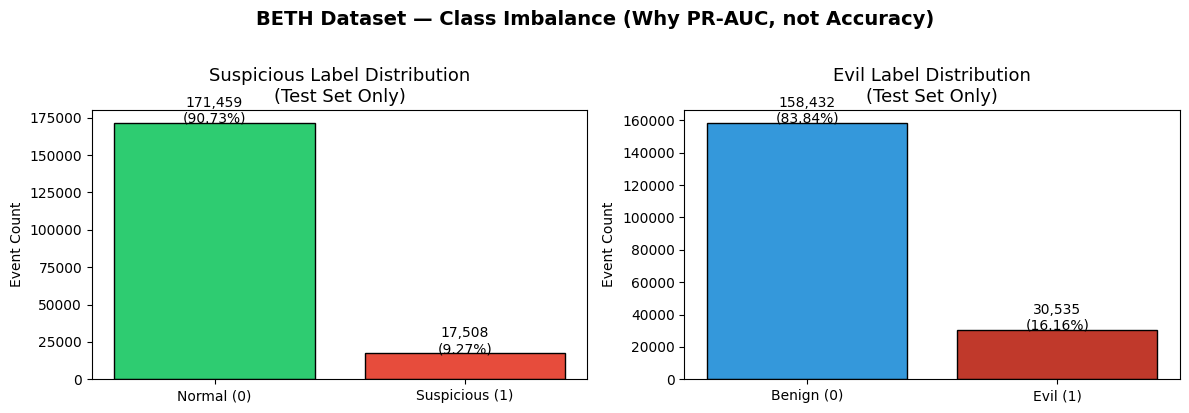

Chart saved ✅


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1 - sus distribution
sus_counts = test_df['sus'].value_counts()
axes[0].bar(['Normal (0)', 'Suspicious (1)'], sus_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Suspicious Label Distribution\n(Test Set Only)', fontsize=13)
axes[0].set_ylabel('Event Count')
for i, v in enumerate(sus_counts.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/len(test_df)*100:.2f}%)',
                 ha='center', fontsize=10)

# Plot 2 - evil distribution
evil_counts = test_df['evil'].value_counts()
axes[1].bar(['Benign (0)', 'Evil (1)'], evil_counts.values,
            color=['#3498db', '#c0392b'], edgecolor='black')
axes[1].set_title('Evil Label Distribution\n(Test Set Only)', fontsize=13)
axes[1].set_ylabel('Event Count')
for i, v in enumerate(evil_counts.values):
    axes[1].text(i, v + 50, f'{v:,}\n({v/len(test_df)*100:.2f}%)',
                 ha='center', fontsize=10)

plt.suptitle('BETH Dataset — Class Imbalance (Why PR-AUC, not Accuracy)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✅")

In [11]:
summary = {
    'train_rows': len(train_df),
    'val_rows': len(val_df),
    'test_rows': len(test_df),
    'columns': list(train_df.columns),
    'train_attack_count': int(train_df['sus'].sum()),
    'test_sus_count': int(test_df['sus'].sum()),
    'test_evil_count': int(test_df['evil'].sum()),
    'sus_rate_pct': round(test_df['sus'].mean()*100, 4),
    'evil_rate_pct': round(test_df['evil'].mean()*100, 4),
}

import json
with open('../data/processed/dataset_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Summary saved to data/processed/dataset_summary.json ✅")
print(json.dumps(summary, indent=2))

Summary saved to data/processed/dataset_summary.json ✅
{
  "train_rows": 763144,
  "val_rows": 188967,
  "test_rows": 188967,
  "columns": [
    "timestamp",
    "processId",
    "threadId",
    "parentProcessId",
    "userId",
    "mountNamespace",
    "processName",
    "hostName",
    "eventId",
    "eventName",
    "stackAddresses",
    "argsNum",
    "returnValue",
    "args",
    "sus",
    "evil"
  ],
  "train_attack_count": 1269,
  "test_sus_count": 171459,
  "test_evil_count": 158432,
  "sus_rate_pct": 90.7349,
  "evil_rate_pct": 83.8411
}
